# Tarea 2 IPD440 - Aprendizaje de máquinas

Nombre: Eduardo Mendoza

Profesor: Nicolás Torres

**Modelo:** BC-ResNet-1 (Kim et al., 2021)  
**Dataset:** Google Speech Commands v2 (12 clases)

## Planteamiento de la Investigación

### Research Question
> *«¿Cómo afecta la degradación de la relación señal a ruido (SNR) al desempeño de clasificación de palabras clave del modelo BC-ResNet-1 sobre Google Speech Commands v2, en términos de exactitud global (Top-1 Accuracy) y de macro F1-score?»*


### Hipótesis
> *«Al degradar la relación señal a ruido por debajo de 10 dB, el desempeño global de BC-ResNet-1 experimentará una caída de exactitud superior al 15% respecto al baseline, exhibiendo una degradación asimétrica donde el F1-score de pares fonéticamente similares (como 'no'-'go', 'up'-'off' y 'down'-'on') en comparación con pares acústicamente ortogonales (como 'stop'-'yes') sufrirá una caída relativa mayor, debido a que el frequency average pooling del bloque residual colapsa la discriminabilidad de los formantes consonánticos en presencia de ruido aditivo.»*

### Variables
* **Condición Baseline (Control):** Inferencia del modelo sin ruido añadido sobre el test set oficial (Top-1 Acc $\approx 96\%$).
* **Variable:** Nivel de potencia de ruido acústico (SNR).

La arquitectura, los pesos y el extractor Log-Mel permanecen fijos.

## Preparación del entorno

In [ ]:
!nvidia-smi

!git clone https://github.com/Qualcomm-AI-research/bcresnet.git
%cd bcresnet

/bin/bash: line 1: nvidia-smi: command not found
Cloning into 'bcresnet'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 13 (delta 1), reused 0 (delta 0), pack-reused 7 (from 1)
Receiving objects: 100% (13/13), 231.00 KiB | 4.12 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/bcresnet


In [ ]:
import sys
import os
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#semilla para reproducir resultados respecto al ruido gaussiano añadido
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

### Descarga del dataset y carga del modelo preentrenado

El benchmark oficial se compone de audios de 1 segundo a 16 [kHz]. Se etiquetan en 12 clases:
* 10 palabras objetivo: *'yes'*, *'no'*, *'up'*, *'down'*, *'left'*, *'right'*, *'on'*, *'off'*, *'stop'*, *'go'*.
* 1 clase de ruido de fondo / silencio (*'silence'*).
* 1 clase de palabras distractoras fuera de vocabulario (*'unknown'*).


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo activo de cómputo: {device}")

# param SpeechCommands v2 y descarga de test
sys.argv = ['main.py', '--ver', '2', '--tau', '1', '--download']
import main

# Instanciar Trainer
trainer = main.Trainer()
trainer.test_loader.num_workers = 0

# cargar arquitectura
model = trainer.model
model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.to(device)
model.eval()

print("modelo cargado")

Se truncaron las últimas líneas 5000 del resultado de transmisión.
Copied ./data/speech_commands_v0.02_split/test/seven/94de6a6a_nohash_4.wav to ./data/speech_commands_v0.02/test_12class/_unknown_/seven_94de6a6a_nohash_4.wav
Copied ./data/speech_commands_v0.02_split/test/seven/3d86b69a_nohash_4.wav to ./data/speech_commands_v0.02/test_12class/_unknown_/seven_3d86b69a_nohash_4.wav
Copied ./data/speech_commands_v0.02_split/test/seven/d103dd6e_nohash_0.wav to ./data/speech_commands_v0.02/test_12class/_unknown_/seven_d103dd6e_nohash_0.wav
Copied ./data/speech_commands_v0.02_split/test/seven/e41a903b_nohash_1.wav to ./data/speech_commands_v0.02/test_12class/_unknown_/seven_e41a903b_nohash_1.wav
Copied ./data/speech_commands_v0.02_split/test/seven/ca4d5368_nohash_0.wav to ./data/speech_commands_v0.02/test_12class/_unknown_/seven_ca4d5368_nohash_0.wav
Copied ./data/speech_commands_v0.02_split/test/seven/220ee1ef_nohash_0.wav to ./data/speech_commands_v0.02/test_12class/_unknown_/seven_220ee1e

### Función de Inyección de Ruido (SNR)

Para modelar la degradación de señal sin generar distorsión, se utilizará la relación señal a ruido ($SNR_{\text{[dB]}}$):

$$SNR_{\text{[dB]}} = 10 \log_{10} \left( \frac{\|x\|_2^2}{\|n_{\text{escalado}}\|_2^2} \right)$$


In [ ]:
def add_noise_snr(waveform: torch.Tensor, snr_db: float) -> torch.Tensor:
    if snr_db is None:
        return waveform
    signal_power = torch.sum(waveform ** 2, dim=-1, keepdim=True)
    noise = torch.randn_like(waveform)
    noise_power = torch.sum(noise ** 2, dim=-1, keepdim=True)
    snr_linear = 10.0 ** (snr_db / 10.0)
    alpha = torch.sqrt(signal_power / (snr_linear * noise_power + 1e-8))
    return waveform + alpha * noise

### Verificación de audio Baseline y con ruido añadido

Antes de ejecutar la inferencia, se extrae una muestra aleatoria de control para corroborar:
1. **Fidelidad Cuantitativa:** Que el SNR medido sobre la señal perturbada coincida con el valor objetivo.
2. **Impacto Espectro-Temporal:** Comparar visualmente la envolvente temporal ($1\text{D}$) frente al espectrograma Log-Mel de 40 bandas ($2\text{D}$) que recibe la red convolucional como entrada, verificando que no ocurra saturación (*clipping*) y que el ruido difuso enmascare progresivamente las formantes.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

mestra seleccionada: 'no' (ID: 5)
verificacion numerica, palabra: 'no'
• Condicion: Limpio (Baseline)  | Energia de Ruido: 0.0000 | SNR Medido: Infinito (Señal Limpia)
• Condicion: 20 dB              | SNR Objetivo: 20 dB | SNR Real Calculado: 20.00 dB
• Condicion: 10 dB              | SNR Objetivo: 10 dB | SNR Real Calculado: 10.00 dB
• Condicion: 5 dB               | SNR Objetivo: 5 dB  | SNR Real Calculado: 5.00 dB
• Condicion: 0 dB               | SNR Objetivo: 0 dB  | SNR Real Calculado: -0.00 dB


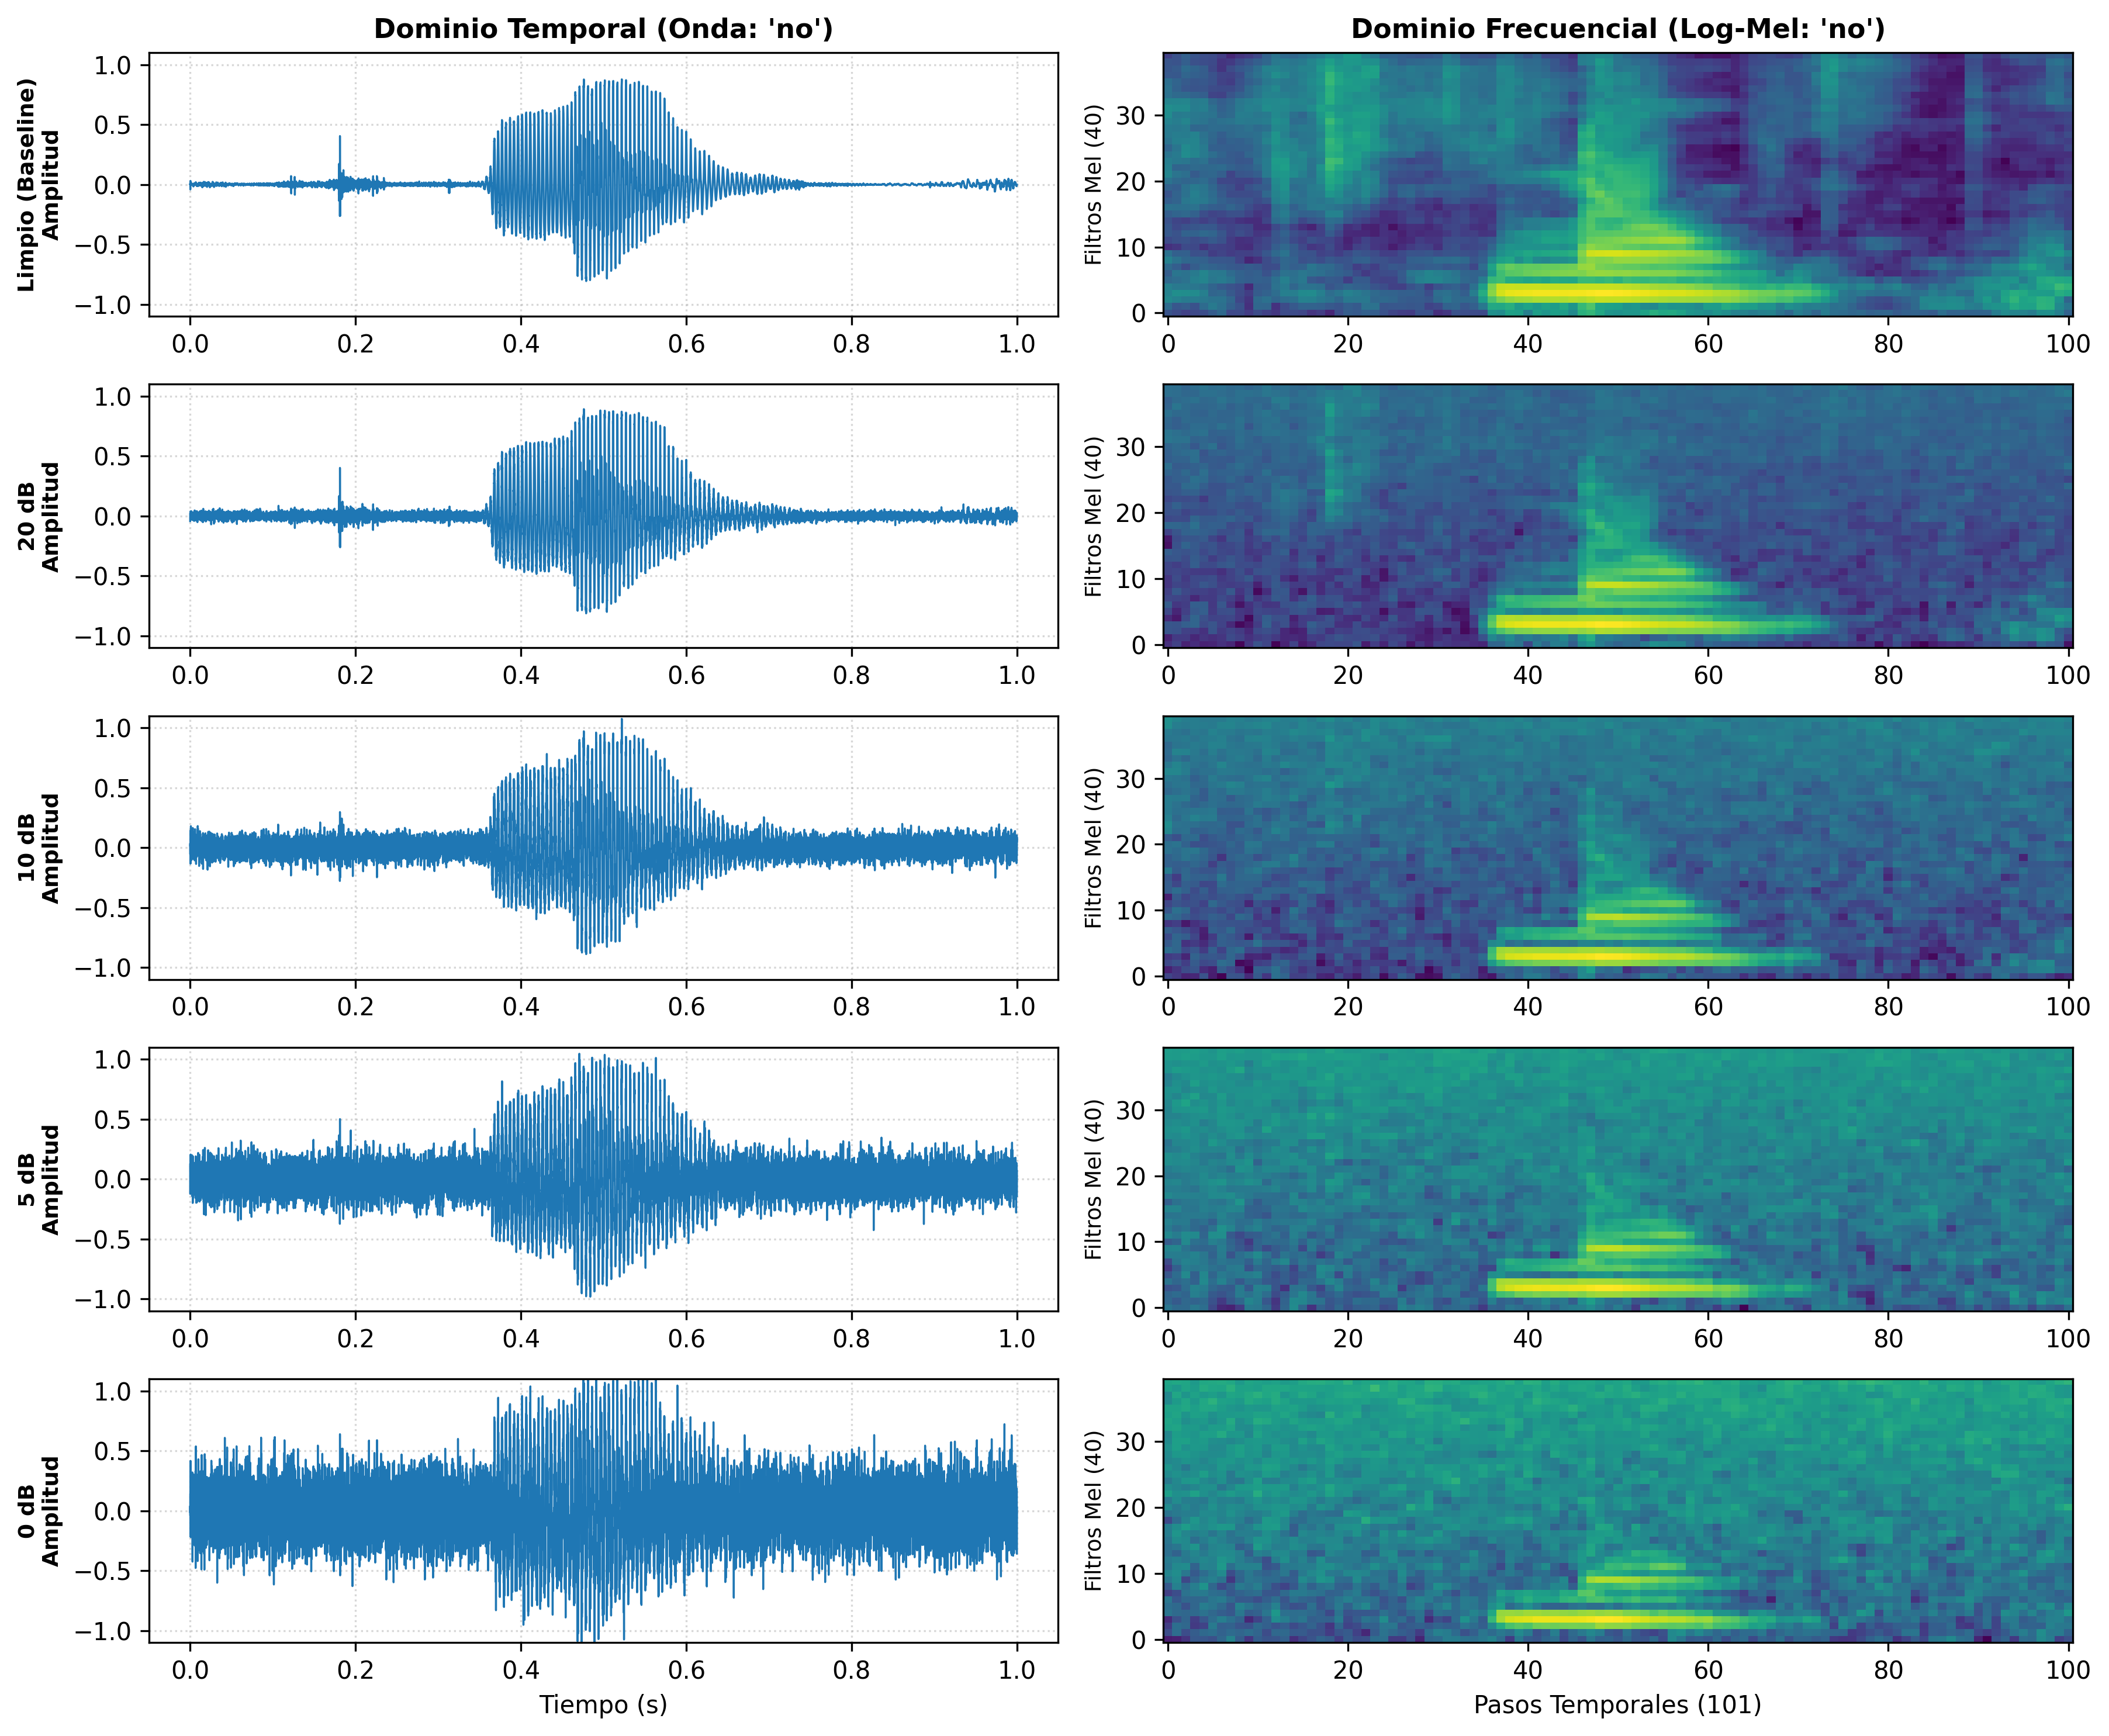

In [ ]:
word_labels = ['silence', 'unknown', 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']

# menu interactivo en Google Colab (no creo que funce en local):
palabra_objetivo = 'no' #@param ['silence', 'unknown', 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']

# busqueda de la palabra
waveform_clean = None
label_idx = word_labels.index(palabra_objetivo)

for batch_audio, batch_labels in trainer.test_loader:
    for wave, lbl in zip(batch_audio, batch_labels):
        if lbl.item() == label_idx:
            waveform_clean = wave.cpu()
            class_name = palabra_objetivo
            break
    if waveform_clean is not None:
        break

if waveform_clean is None:
    raise ValueError(f"No se encontró ninguna muestra de la clase '{palabra_objetivo}' en el conjunto de prueba.")

print(f"mestra seleccionada: '{class_name}' (ID: {label_idx})")

#generacion del ruido e inyeccion al audio
snr_targets = [None, 20.0, 10.0, 5.0, 0.0]
signals = {}
snr_measured = {}

for snr in snr_targets:
    tag = "Limpio (Baseline)" if snr is None else f"{int(snr)} dB"
    if snr is None:
        noisy = waveform_clean.clone()
        snr_calc = float('inf')
    else:
        # Inyección de ruido
        noisy = add_noise_snr(waveform_clean.clone().unsqueeze(0), snr_db=snr).squeeze(0)

        # SNR medido
        noise_residual = noisy - waveform_clean
        p_signal = torch.sum(waveform_clean ** 2)
        p_noise = torch.sum(noise_residual ** 2)
        snr_calc = 10.0 * torch.log10(p_signal / (p_noise + 1e-12)).item()

    signals[tag] = noisy
    snr_measured[tag] = snr_calc

#resultados numericos
print(f"verificacion numerica, palabra: '{class_name}'")
for tag, measured in snr_measured.items():
    if np.isinf(measured):
        print(f"• Condicion: {tag:<18} | Energia de Ruido: 0.0000 | SNR Medido: Infinito (Señal Limpia)")
    else:
        print(f"• Condicion: {tag:<18} | SNR Objetivo: {tag:<5} | SNR Real Calculado: {measured:.2f} dB")

#graficos
fig, axes = plt.subplots(len(signals), 2, figsize=(12, 10), dpi=300)
time_axis = np.linspace(0, 1.0, 16000)
target_tensor = torch.tensor([label_idx], device=device)

for idx, (tag, wave) in enumerate(signals.items()):
    #onda en el tiempo
    axes[idx, 0].plot(time_axis, wave.squeeze().numpy(), color='#1f77b4', lw=0.8)
    axes[idx, 0].set_ylim([-1.1, 1.1])
    axes[idx, 0].set_ylabel(f"{tag}\nAmplitud", fontsize=9, fontweight='bold')
    axes[idx, 0].grid(True, linestyle=':', alpha=0.5)
    if idx == 0:
        axes[idx, 0].set_title(f"Dominio Temporal (Onda: '{class_name}')", fontsize=11, fontweight='bold')
    if idx == len(signals) - 1:
        axes[idx, 0].set_xlabel("Tiempo (s)", fontsize=10)

    # Espectrograma Log-Mel
    with torch.no_grad():
        spec = trainer.preprocess_test(
            wave.unsqueeze(0).to(device),
            labels=target_tensor,
            is_train=False,
            augment=False
        )
        log_mel = spec.squeeze().cpu().numpy()

    im = axes[idx, 1].imshow(log_mel, aspect='auto', origin='lower', cmap='viridis')
    axes[idx, 1].set_ylabel("Filtros Mel (40)", fontsize=9)
    if idx == 0:
        axes[idx, 1].set_title(f"Dominio Frecuencial (Log-Mel: '{class_name}')", fontsize=11, fontweight='bold')
    if idx == len(signals) - 1:
        axes[idx, 1].set_xlabel("Pasos Temporales (101)", fontsize=10)

plt.tight_layout()
plt.savefig(f"figura_verificacion_{class_name}.png", dpi=300)
plt.show()

In [ ]:
word_labels = ['silence', 'unknown', 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']


palabra_audio = 'no' #@param ['silence', 'unknown', 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']

target_idx = word_labels.index(palabra_audio)
selected_waveform = None

# buscar
for batch_audio, batch_labels in trainer.test_loader:
    for wave, lbl in zip(batch_audio, batch_labels):
        if lbl.item() == target_idx:
            selected_waveform = wave.cpu()
            break
    if selected_waveform is not None:
        break

if selected_waveform is None:
    raise ValueError(f"No se encontró una muestra para la clase '{palabra_audio}' en el test set.")


snr_playback = [None, 20.0, 10.0, 5.0, 0.0]

descripciones = {
    None: "Baseline",
    20.0: "Ruido Leve (SNR = 20 dB)",
    10.0: "Ruido Moderado (SNR = 10 dB)",
    5.0:  "Ruido Severo (SNR = 5 dB)",
    0.0:  "Ruido Crítico (SNR = 0 dB)"
}

print(f"palabra: '{palabra_audio.upper()}'")

for snr in snr_playback:
    tag = "Limpio (Baseline)" if snr is None else f"{int(snr)} dB"
    desc = descripciones[snr]

    if snr is None:
        wave_playback = selected_waveform.clone()
    else:
        wave_playback = add_noise_snr(selected_waveform.clone().unsqueeze(0), snr_db=snr).squeeze(0)

    audio_np = wave_playback.squeeze().numpy()

    print(f"condicion  {tag}: {desc}")
    display(ipd.Audio(audio_np, rate=16000))

palabra: 'NO'
condicion  Limpio (Baseline): Baseline


condicion  20 dB: Ruido Leve (SNR = 20 dB)


condicion  10 dB: Ruido Moderado (SNR = 10 dB)


condicion  5 dB: Ruido Severo (SNR = 5 dB)


condicion  0 dB: Ruido Crítico (SNR = 0 dB)


## Evaluación Experimental

Se carga el modelo entrenado (`best_model.pt`) y se evalúa la partición de prueba bajo cinco condiciones:
1. **Limpio (Baseline)**
2. **SNR = 20 dB (Ruido leve)**
3. **SNR = 10 dB (Ruido moderado)**
4. **SNR = 5 dB (Ruido severo)**
5. **SNR = 0 dB (Ruido crítico: igual potencia de voz y ruido)**


In [ ]:
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

model.to(device)
model.eval()

snr_conditions = [None, 20.0, 10.0, 5.0, 0.0]
labels_kws = ['silence', 'unknown', 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']

tabla_resultados = []
matrices_dispersion = {}

print("iniciando experimento")

for snr in snr_conditions:
    etiqueta = "Limpio (Baseline)" if snr is None else f"Ruido {int(snr)} dB"
    print(f"\n evaluando en condición: {etiqueta}...")

    y_predichas = []
    y_reales = []

    with torch.no_grad():
        for inputs, targets in trainer.test_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # aplicar snr
            inputs_perturbados = add_noise_snr(inputs, snr)

            #preprocesamiento espectral
            espectrograma = trainer.preprocess_test(inputs_perturbados, targets, is_train=False, augment=False)
            logits = model(espectrograma)
            preds = logits.argmax(dim=-1)

            y_predichas.extend(preds.cpu().numpy())
            y_reales.extend(targets.cpu().numpy())

    acc = accuracy_score(y_reales, y_predichas) * 100.0
    macro_f1 = f1_score(y_reales, y_predichas, average='macro', zero_division=0)
    f1_clases = f1_score(y_reales, y_predichas, average=None, zero_division=0)

    #registro
    fila = {
        "Condición": etiqueta,
        "SNR (dB)": "Infinito" if snr is None else snr,
        "Top-1 Accuracy (%)": round(acc, 2),
        "Macro F1": round(macro_f1, 4)
    }

    for idx, nombre_clase in enumerate(labels_kws):
        fila[f"F1_{nombre_clase}"] = round(f1_clases[idx], 4)

    tabla_resultados.append(fila)
    matrices_dispersion[etiqueta] = confusion_matrix(y_reales, y_predichas)

    print(f"-> Acc: {acc:.2f}% | Macro F1: {macro_f1:.4f} ")

# guasrdar resultados
df_experimento = pd.DataFrame(tabla_resultados)
df_experimento.to_csv("comparativa_completa_snr_12clases.csv", index=False)
np.save("matrices_confusion_snr.npy", matrices_dispersion)

print("resultados")
display(df_experimento[["Condición", "SNR (dB)", "Top-1 Accuracy (%)", "Macro F1"]])

iniciando experimento

 evaluando en condición: Limpio (Baseline)...
-> Acc: 96.05% | Macro F1: 0.9603 

 evaluando en condición: Ruido 20 dB...
-> Acc: 94.97% | Macro F1: 0.9493 

 evaluando en condición: Ruido 10 dB...
-> Acc: 93.07% | Macro F1: 0.9301 

 evaluando en condición: Ruido 5 dB...
-> Acc: 90.51% | Macro F1: 0.9045 

 evaluando en condición: Ruido 0 dB...
-> Acc: 85.05% | Macro F1: 0.8484 
resultados


,Condición,SNR (dB),Top-1 Accuracy (%),Macro F1
0,Limpio (Baseline),Infinito,96.05,0.9603
1,Ruido 20 dB,20.0,94.97,0.9493
2,Ruido 10 dB,10.0,93.07,0.9301
3,Ruido 5 dB,5.0,90.51,0.9045
4,Ruido 0 dB,0.0,85.05,0.8484


In [ ]:
fila_limpio = df_experimento[df_experimento["Condición"] == "Limpio (Baseline)"].iloc[0]
fila_0db = df_experimento[df_experimento["Condición"] == "Ruido 0 dB"].iloc[0]

analisis_asimetria = []

for clase in labels_kws:
    col = f"F1_{clase}"
    f1_base = fila_limpio[col]
    f1_ruido = fila_0db[col]
    delta_absoluto = f1_base - f1_ruido
    caida_relativa_pct = (delta_absoluto / (f1_base + 1e-8)) * 100.0

    analisis_asimetria.append({
        "Comando": clase,
        "F1 Baseline": f1_base,
        "F1 (0 dB)": f1_ruido,
        "delta F1 Absoluto": round(delta_absoluto, 4),
        "Caida Relativa (%)": round(caida_relativa_pct, 2)
    })

df_asimetria = pd.DataFrame(analisis_asimetria).sort_values(by="Caida Relativa (%)", ascending=False).reset_index(drop=True)
df_asimetria.to_csv("ranking_degradacion_clases.csv", index=False)

# Comparar con la caída macro promedio
delta_macro = (fila_limpio["Macro F1"] - fila_0db["Macro F1"])
caida_macro_pct = (delta_macro / fila_limpio["Macro F1"]) * 100.0

print(f"Caida Macro F1  global: {caida_macro_pct:.2f}% (Δ = {delta_macro:.4f})\n")
print("degradacion para cada clase")
display(df_asimetria)

Caida Macro F1  global: 11.65% (Δ = 0.1119)

degradacion para cada clase


,Comando,F1 Baseline,F1 (0 dB),delta F1 Absoluto,Caida Relativa (%)
0,unknown,0.8977,0.7171,0.1806,20.12
1,no,0.9644,0.7734,0.1910,19.81
2,go,0.9494,0.7871,0.1623,17.10
3,off,0.9489,0.8293,0.1196,12.60
4,down,0.9428,0.8398,0.1030,10.92
5,up,0.9604,0.8664,0.0940,9.79
6,stop,0.9915,0.8968,0.0947,9.55
7,silence,0.9843,0.8928,0.0915,9.30
8,left,0.9712,0.8825,0.0887,9.13
9,yes,0.9846,0.9040,0.0806,8.19


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar métricas del experimento
if os.path.exists("comparativa_completa_snr_12clases.csv"):
    df_metricas = pd.read_csv("comparativa_completa_snr_12clases.csv")
else:
    df_metricas = df_experimento  # Fallback si está en memoria

# 2. Cargar matrices de confusión
cm_dict = np.load("matrices_confusion_snr.npy", allow_pickle=True).item()

# 3. Etiquetas canónicas del benchmark
labels_kws = ['silence', 'unknown', 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']

# 4. Configuración visual estándar
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 10, 'figure.autolayout': True})

print("✓ Métricas y matrices cargadas correctamente.")
display(df_metricas[["Condición", "SNR (dB)", "Top-1 Accuracy (%)", "Macro F1", "F1_no", "F1_go"]])

✓ Métricas y matrices cargadas correctamente.


,Condición,SNR (dB),Top-1 Accuracy (%),Macro F1,F1_no,F1_go
0,Limpio (Baseline),Infinito,96.05,0.9603,0.9644,0.9494
1,Ruido 20 dB,20.0,94.97,0.9493,0.9560,0.9387
2,Ruido 10 dB,10.0,93.07,0.9301,0.9380,0.9073
3,Ruido 5 dB,5.0,90.51,0.9045,0.8886,0.8667
4,Ruido 0 dB,0.0,85.05,0.8484,0.7734,0.7871


### Curva de Degradación Acústica Global y Homófonos

Se contrasta la trayectoria de la exactitud global (*Top-1 Accuracy*) y el *Macro F1-Score* frente al comportamiento individual de los comandos fonéticamente homófonos (*"no"* y *"go"*). La línea vertical punteada marca el umbral de los 10 dB definido en la hipótesis como el punto de quiebre acústico del sistema.

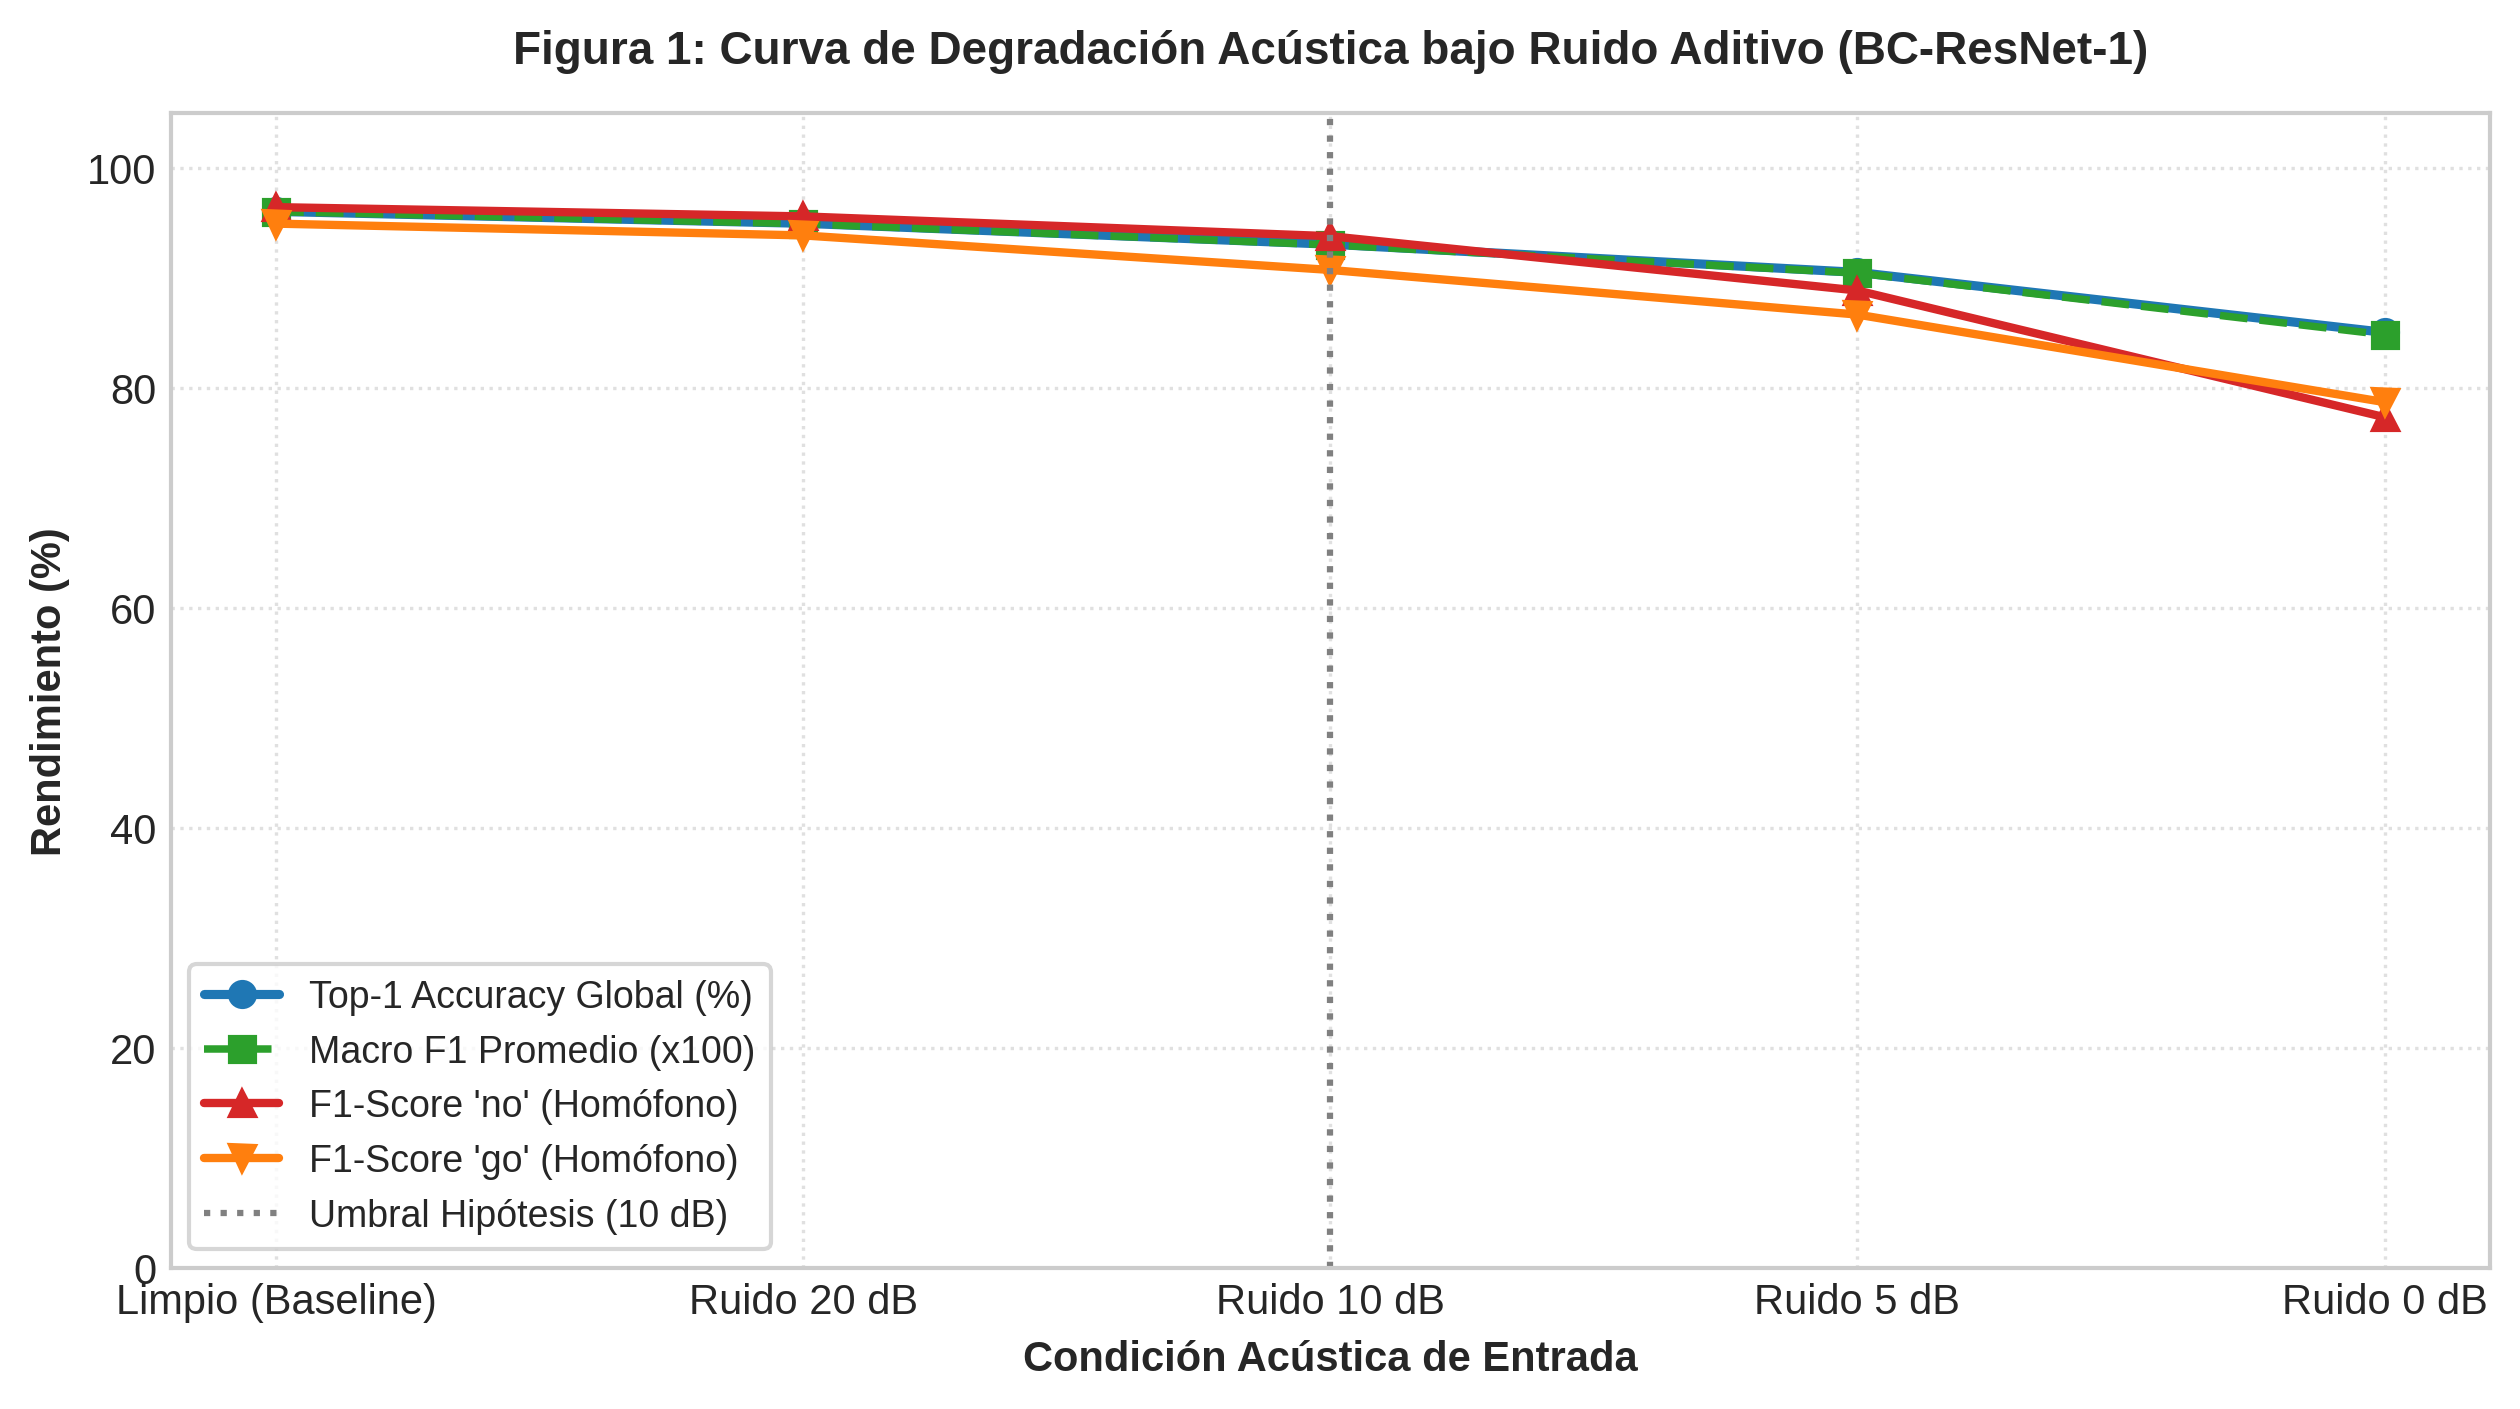

✓ 'figura1_curva_degradacion.png' exportada con éxito.


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=300)

condiciones = df_metricas["Condición"]

# Curvas de desempeño
ax.plot(condiciones, df_metricas["Top-1 Accuracy (%)"], marker='o', lw=2.2, color='#1f77b4', label='Top-1 Accuracy Global (%)')
ax.plot(condiciones, df_metricas["Macro F1"] * 100, marker='s', lw=1.8, linestyle='--', color='#2ca02c', label='Macro F1 Promedio (x100)')
ax.plot(condiciones, df_metricas["F1_no"] * 100, marker='^', lw=2.0, linestyle='-', color='#d62728', label="F1-Score 'no' (Homófono)")
ax.plot(condiciones, df_metricas["F1_go"] * 100, marker='v', lw=2.0, linestyle='-', color='#ff7f0e', label="F1-Score 'go' (Homófono)")

# Línea de umbral crítico de la hipótesis (SNR = 10 dB)
ax.axvline(x=2, color='gray', linestyle=':', lw=1.5, label='Umbral Hipótesis (10 dB)')

ax.set_title("Figura 1: Curva de Degradación Acústica bajo Ruido Aditivo (BC-ResNet-1)", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Condición Acústica de Entrada", fontsize=10, fontweight='bold')
ax.set_ylabel("Rendimiento (%)", fontsize=10, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(frameon=True, loc='lower left', fontsize=9)

plt.savefig("figura1_curva_degradacion.png", dpi=300)
plt.show()
print("✓ 'figura1_curva_degradacion.png' exportada con éxito.")

### Ranking de Vulnerabilidad Acústica por Clase

Para evaluar la asimetría de la degradación, se calcula la pérdida relativa porcentual de F1-score entre el audio limpio y la condición extrema de 0 dB para cada una de las 12 clases:

$$\Delta F1_{\text{rel}} = \frac{F1_{\text{Base}} - F1_{\text{0dB}}}{F1_{\text{Base}}} \times 100$$

La línea punteada indica el promedio macro del sistema. Las clases situadas a la derecha de esta línea experimentan una vulnerabilidad superior a la media.

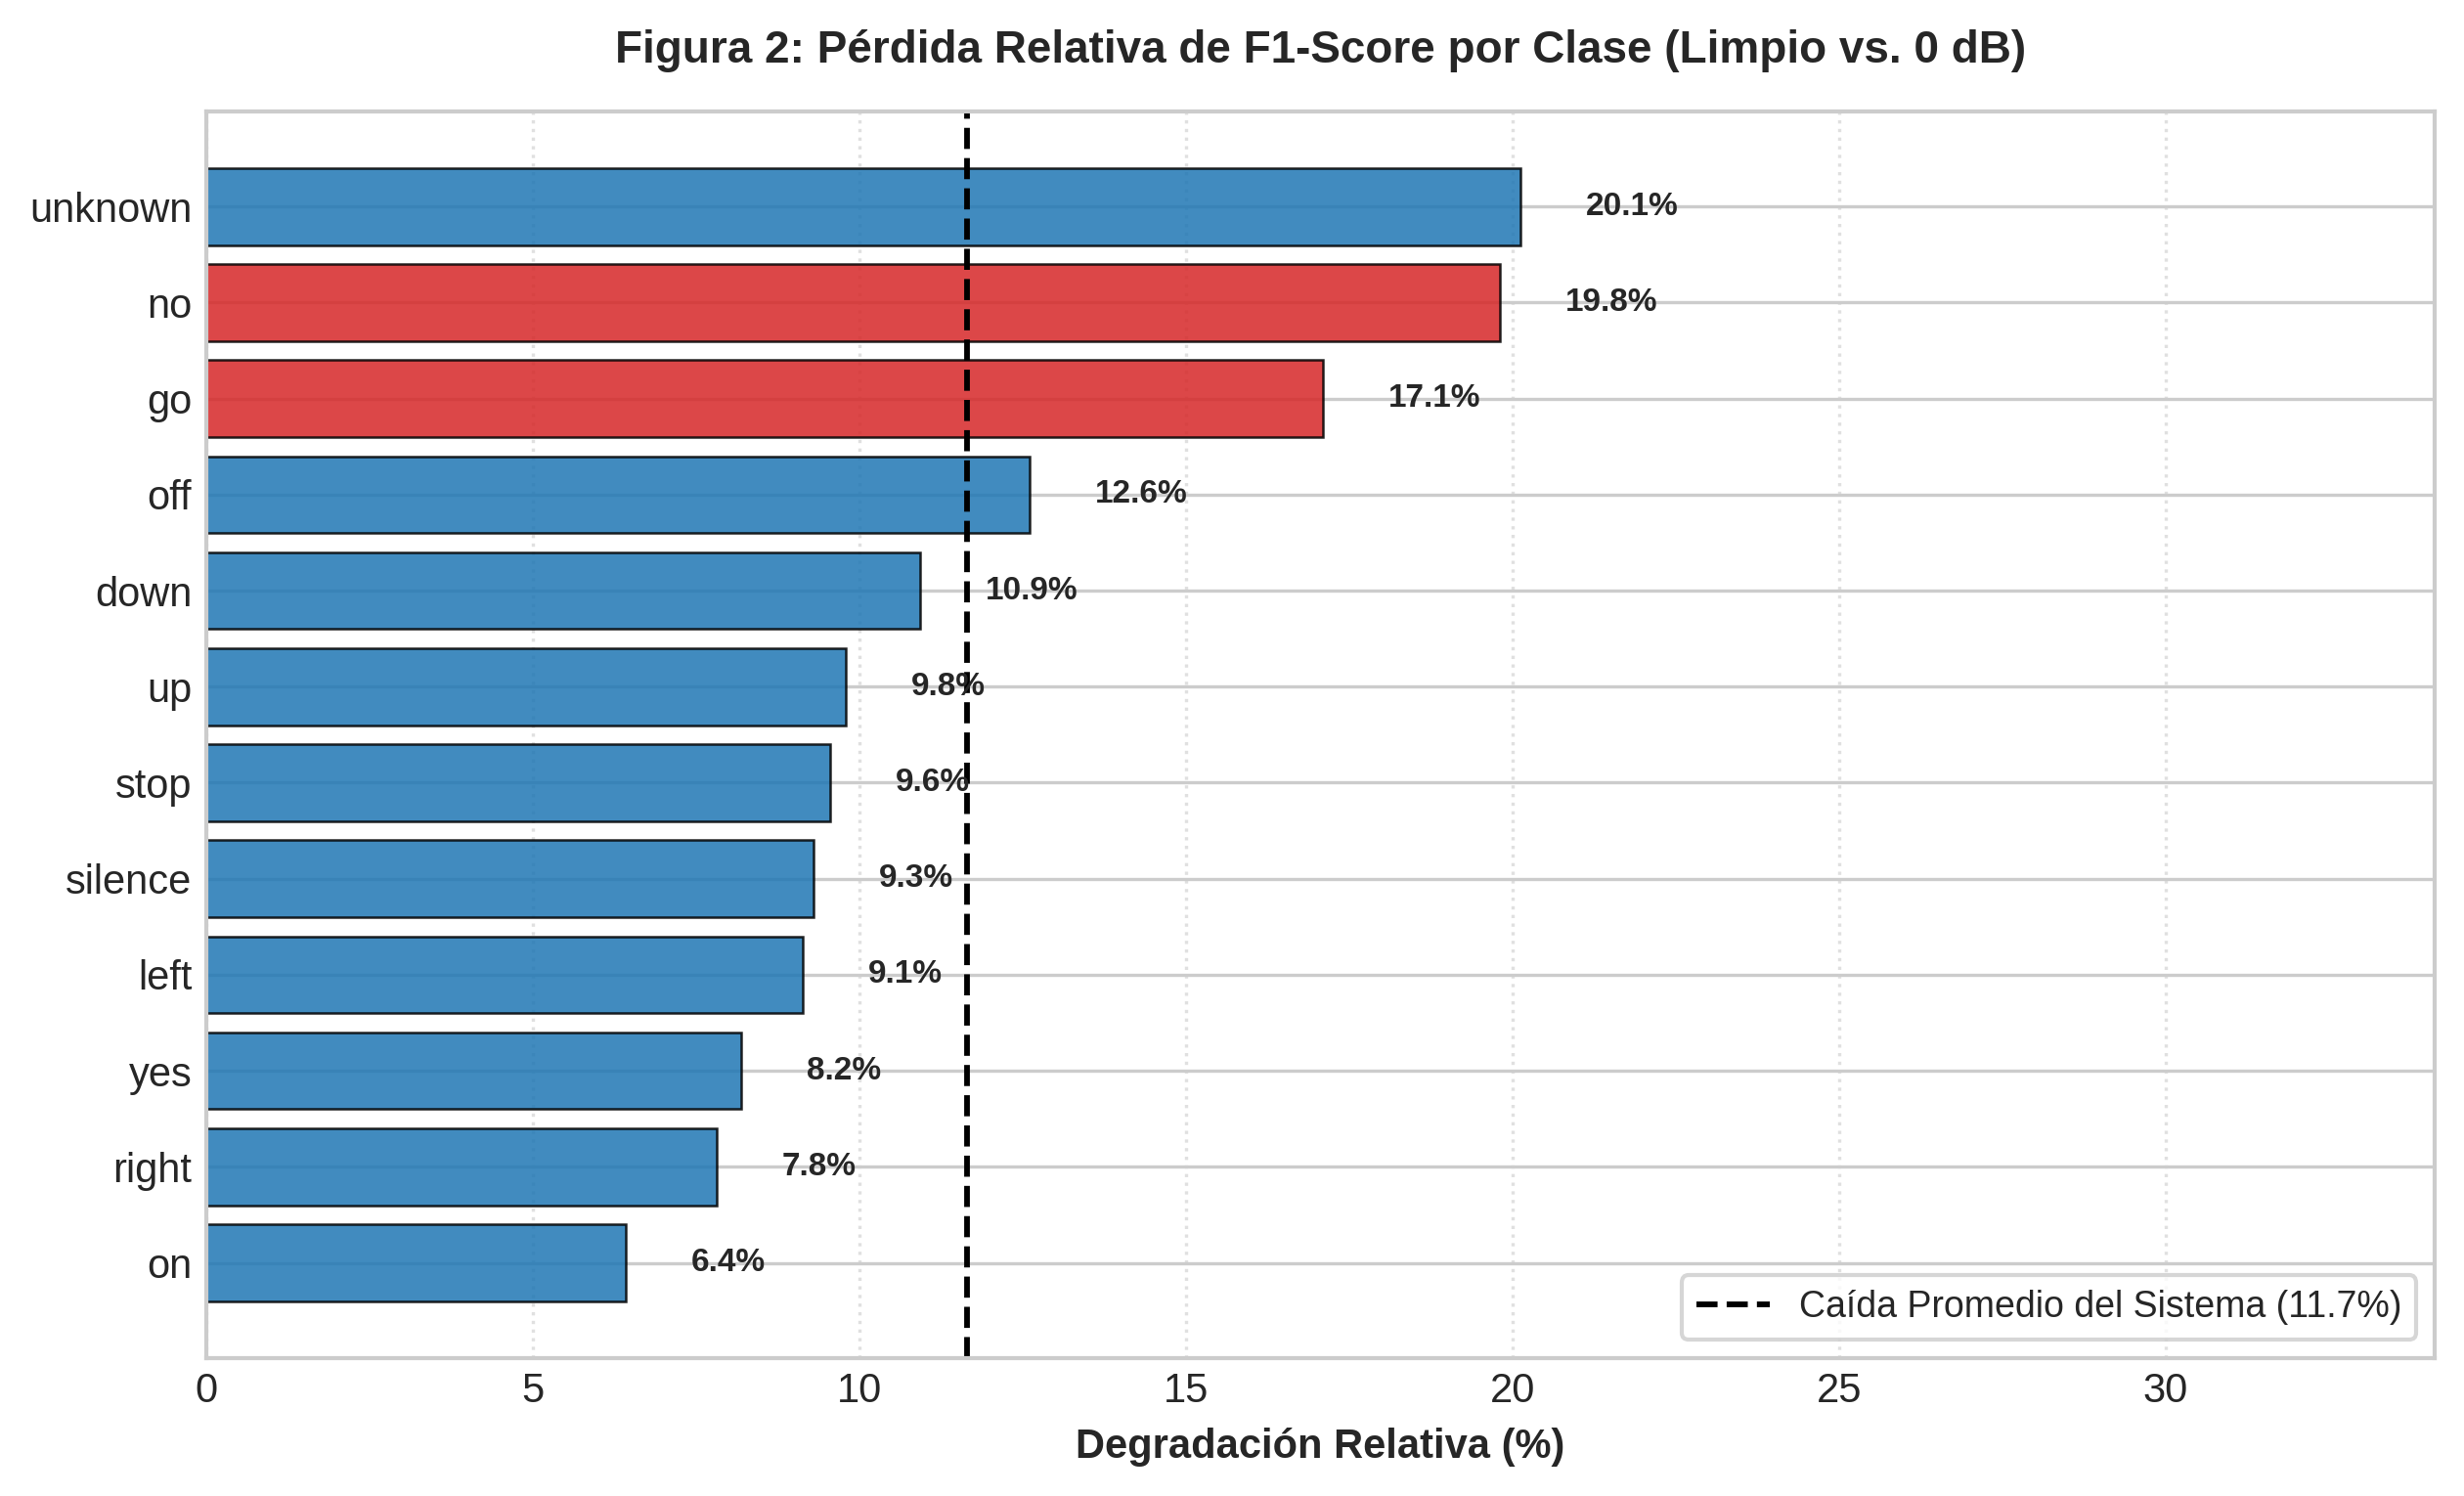

✓ 'figura2_ranking_asimetria.png' exportada con éxito.


In [ ]:
fila_base = df_metricas[df_metricas["Condición"] == "Limpio (Baseline)"].iloc[0]
fila_0db = df_metricas[df_metricas["Condición"] == "Ruido 0 dB"].iloc[0]

caidas = []
for c in labels_kws:
    f1_init = fila_base[f"F1_{c}"]
    f1_end = fila_0db[f"F1_{c}"]
    caida_rel = ((f1_init - f1_end) / (f1_init + 1e-8)) * 100.0
    caidas.append({"Clase": c, "Caida_Pct": caida_rel})

df_caidas = pd.DataFrame(caidas).sort_values(by="Caida_Pct", ascending=True)

# Caída promedio macro
caida_macro = ((fila_base["Macro F1"] - fila_0db["Macro F1"]) / fila_base["Macro F1"]) * 100.0

fig, ax2 = plt.subplots(figsize=(8.5, 5.2), dpi=300)

# Destacar palabras homófonas en rojo
colores = ['#d62728' if c in ['no', 'go'] else '#1f77b4' for c in df_caidas["Clase"]]

barras = ax2.barh(df_caidas["Clase"], df_caidas["Caida_Pct"], color=colores, alpha=0.85, edgecolor='black', linewidth=0.6)
ax2.axvline(x=caida_macro, color='black', linestyle='--', lw=1.4, label=f'Caída Promedio del Sistema ({caida_macro:.1f}%)')

# Valores numéricos al final de cada barra
for b in barras:
    w = b.get_width()
    ax2.text(w + 1.0, b.get_y() + b.get_height() / 2.0, f"{w:.1f}%", va='center', fontsize=8, fontweight='bold')

ax2.set_title("Figura 2: Pérdida Relativa de F1-Score por Clase (Limpio vs. 0 dB)", fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel("Degradación Relativa (%)", fontsize=10, fontweight='bold')
ax2.set_xlim(0, max(df_caidas["Caida_Pct"]) + 14)
ax2.grid(True, linestyle=':', alpha=0.6, axis='x')
ax2.legend(frameon=True, loc='lower right', fontsize=9)

plt.savefig("figura2_ranking_asimetria.png", dpi=300)
plt.show()
print("✓ 'figura2_ranking_asimetria.png' exportada con éxito.")

### Matrices de Confusión Normalizadas (Baseline vs. 0 dB)

Se normalizan las matrices a lo largo de las filas (sensibilidad / *recall* por clase) para evidenciar las transiciones erróneas:
* **Condición (a):** Distribución diagonal casi ideal en audio limpio.
* **Condición (b):** Dispersión de predicciones en presencia de ruido severo (0 dB), permitiendo distinguir si los errores se deben a confusiones entre comandos homófonos o a absorción hacia la clase distractor (*"unknown"*).

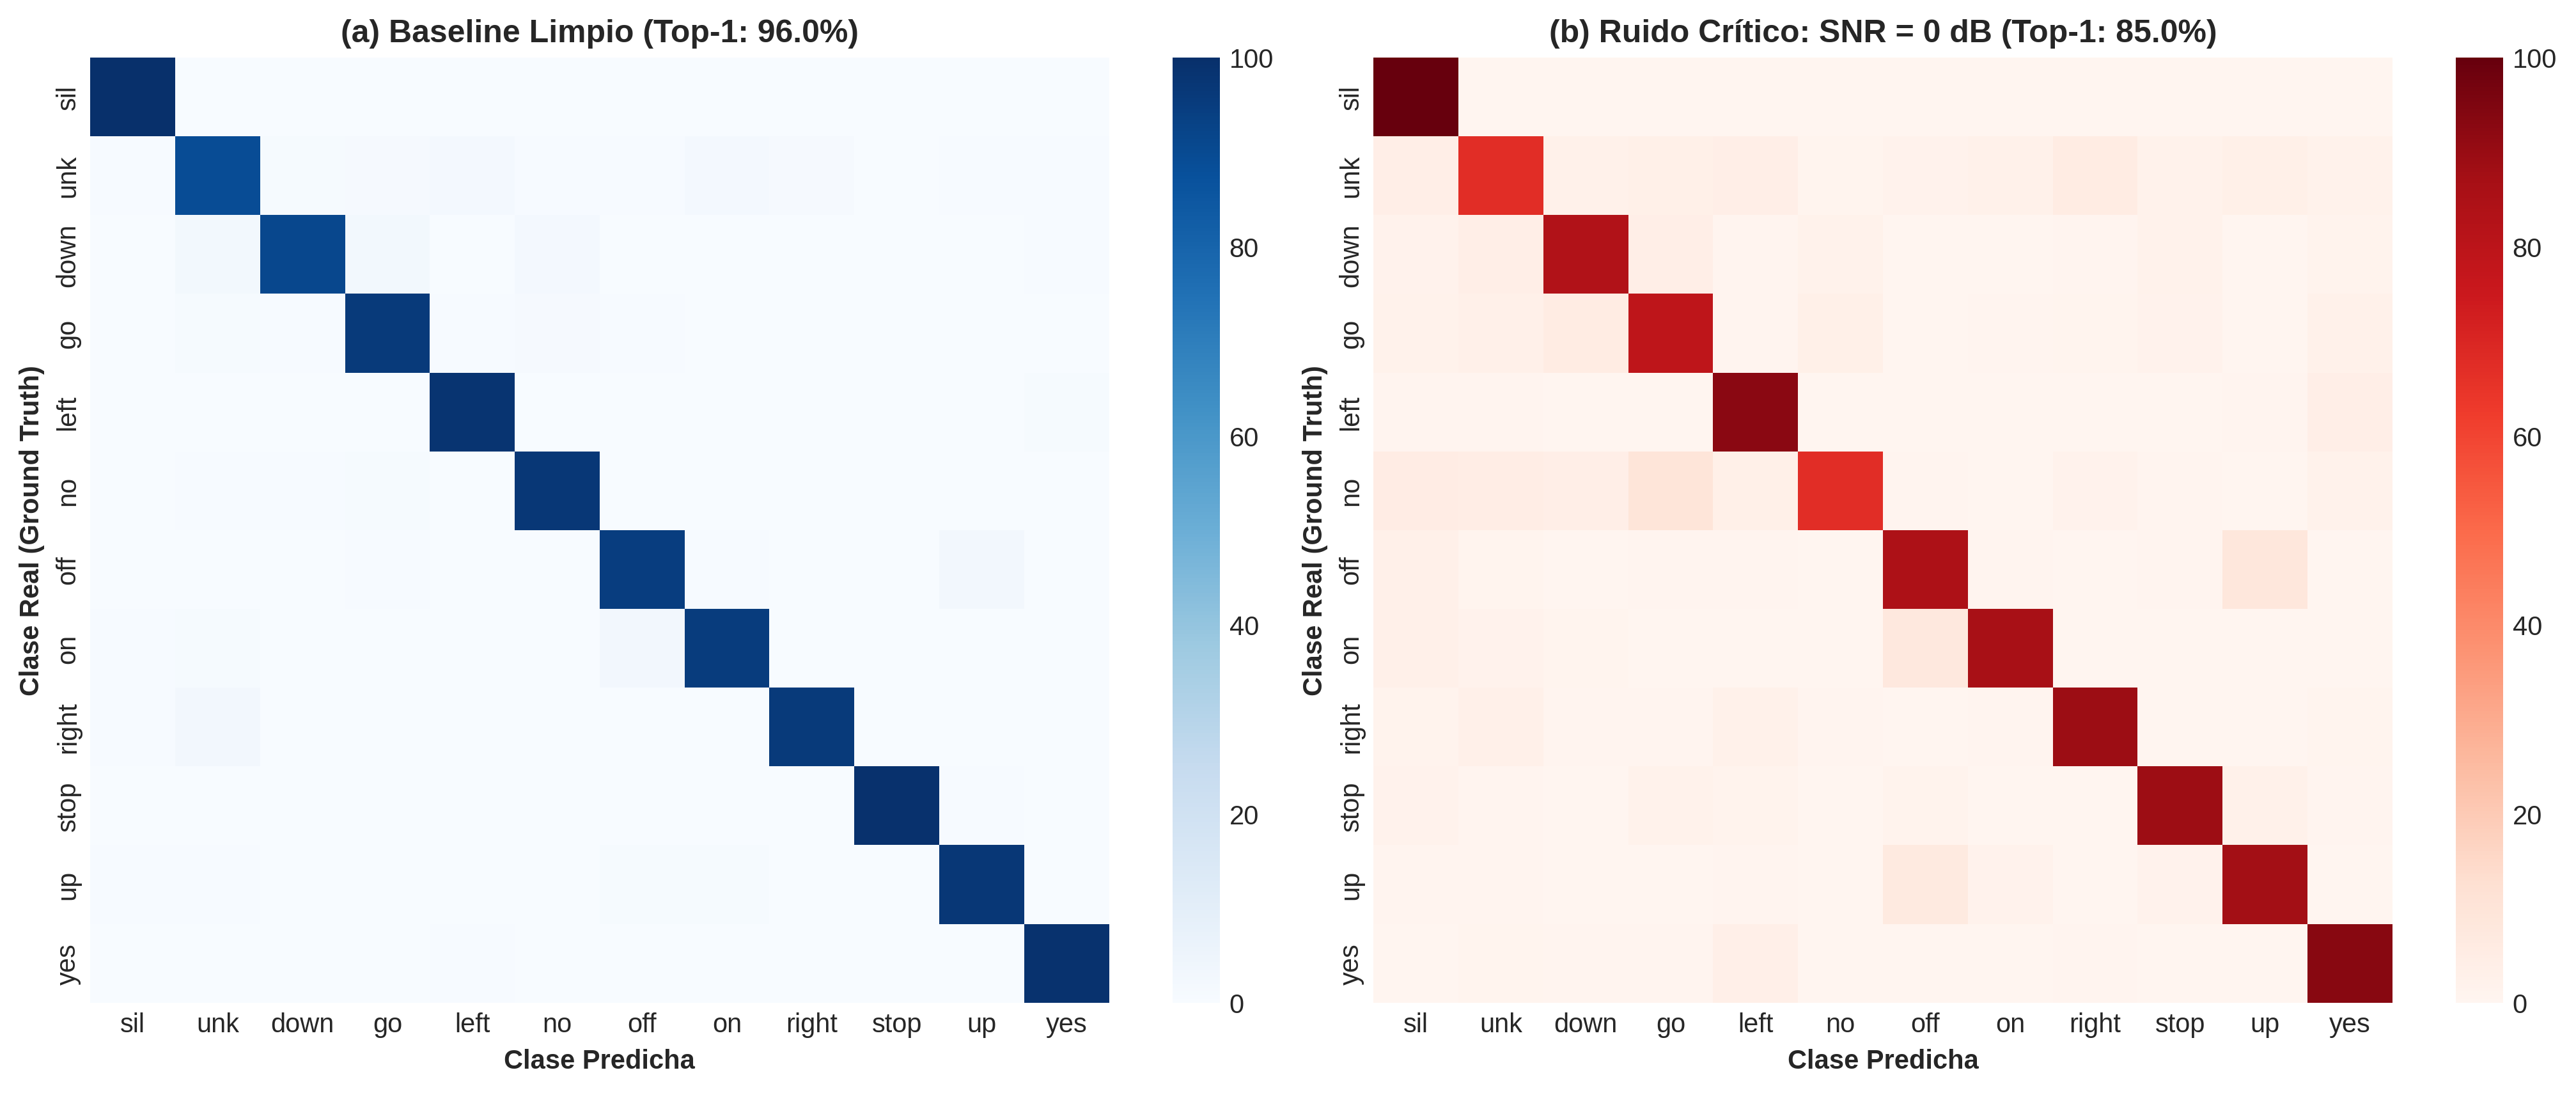

✓ 'figura3_matrices_confusion.png' exportada con éxito.


In [ ]:
labels_abrev = ['sil', 'unk', 'down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes']

# Normalizar matrices por fila (Recall por clase)
cm_limpio_norm = cm_dict["Limpio (Baseline)"].astype('float') / cm_dict["Limpio (Baseline)"].sum(axis=1)[:, np.newaxis]
cm_0db_norm = cm_dict["Ruido 0 dB"].astype('float') / cm_dict["Ruido 0 dB"].sum(axis=1)[:, np.newaxis]

fig, (ax_cm1, ax_cm2) = plt.subplots(1, 2, figsize=(14, 5.8), dpi=300)

# Mapa de calor limpio
sns.heatmap(cm_limpio_norm * 100, ax=ax_cm1, annot=False, cmap='Blues', vmin=0, vmax=100,
            xticklabels=labels_abrev, yticklabels=labels_abrev, cbar=True)
ax_cm1.set_title(f"(a) Baseline Limpio (Top-1: {fila_base['Top-1 Accuracy (%)']:.1f}%)", fontweight='bold')
ax_cm1.set_xlabel("Clase Predicha", fontweight='bold')
ax_cm1.set_ylabel("Clase Real (Ground Truth)", fontweight='bold')

# Mapa de calor a 0 dB
sns.heatmap(cm_0db_norm * 100, ax=ax_cm2, annot=False, cmap='Reds', vmin=0, vmax=100,
            xticklabels=labels_abrev, yticklabels=labels_abrev, cbar=True)
ax_cm2.set_title(f"(b) Ruido Crítico: SNR = 0 dB (Top-1: {fila_0db['Top-1 Accuracy (%)']:.1f}%)", fontweight='bold')
ax_cm2.set_xlabel("Clase Predicha", fontweight='bold')
ax_cm2.set_ylabel("Clase Real (Ground Truth)", fontweight='bold')

plt.savefig("figura3_matrices_confusion.png", dpi=300)
plt.show()
print("✓ 'figura3_matrices_confusion.png' exportada con éxito.")

=== EVOLUCIÓN DE LA TASA DE CONFUSIÓN CRUZADA (%) POR PAR FONÉTICO ===


,Condición,no ↔ go (Rima /oʊ/),"up ↔ off (Labiales /p/, /f/)",down ↔ on (Nasal /n/),yes ↔ left (Vocal /ɛ/),stop ↔ yes (Control Ortogonal)
0,Limpio (Baseline),1.12,1.93,0.00,0.84,0.00
1,Ruido 20 dB,0.99,3.39,0.00,0.96,0.00
2,Ruido 10 dB,2.48,5.08,0.12,1.68,0.12
3,Ruido 5 dB,3.84,6.41,0.00,2.29,0.00
4,Ruido 0 dB,6.44,7.50,0.62,3.85,0.36


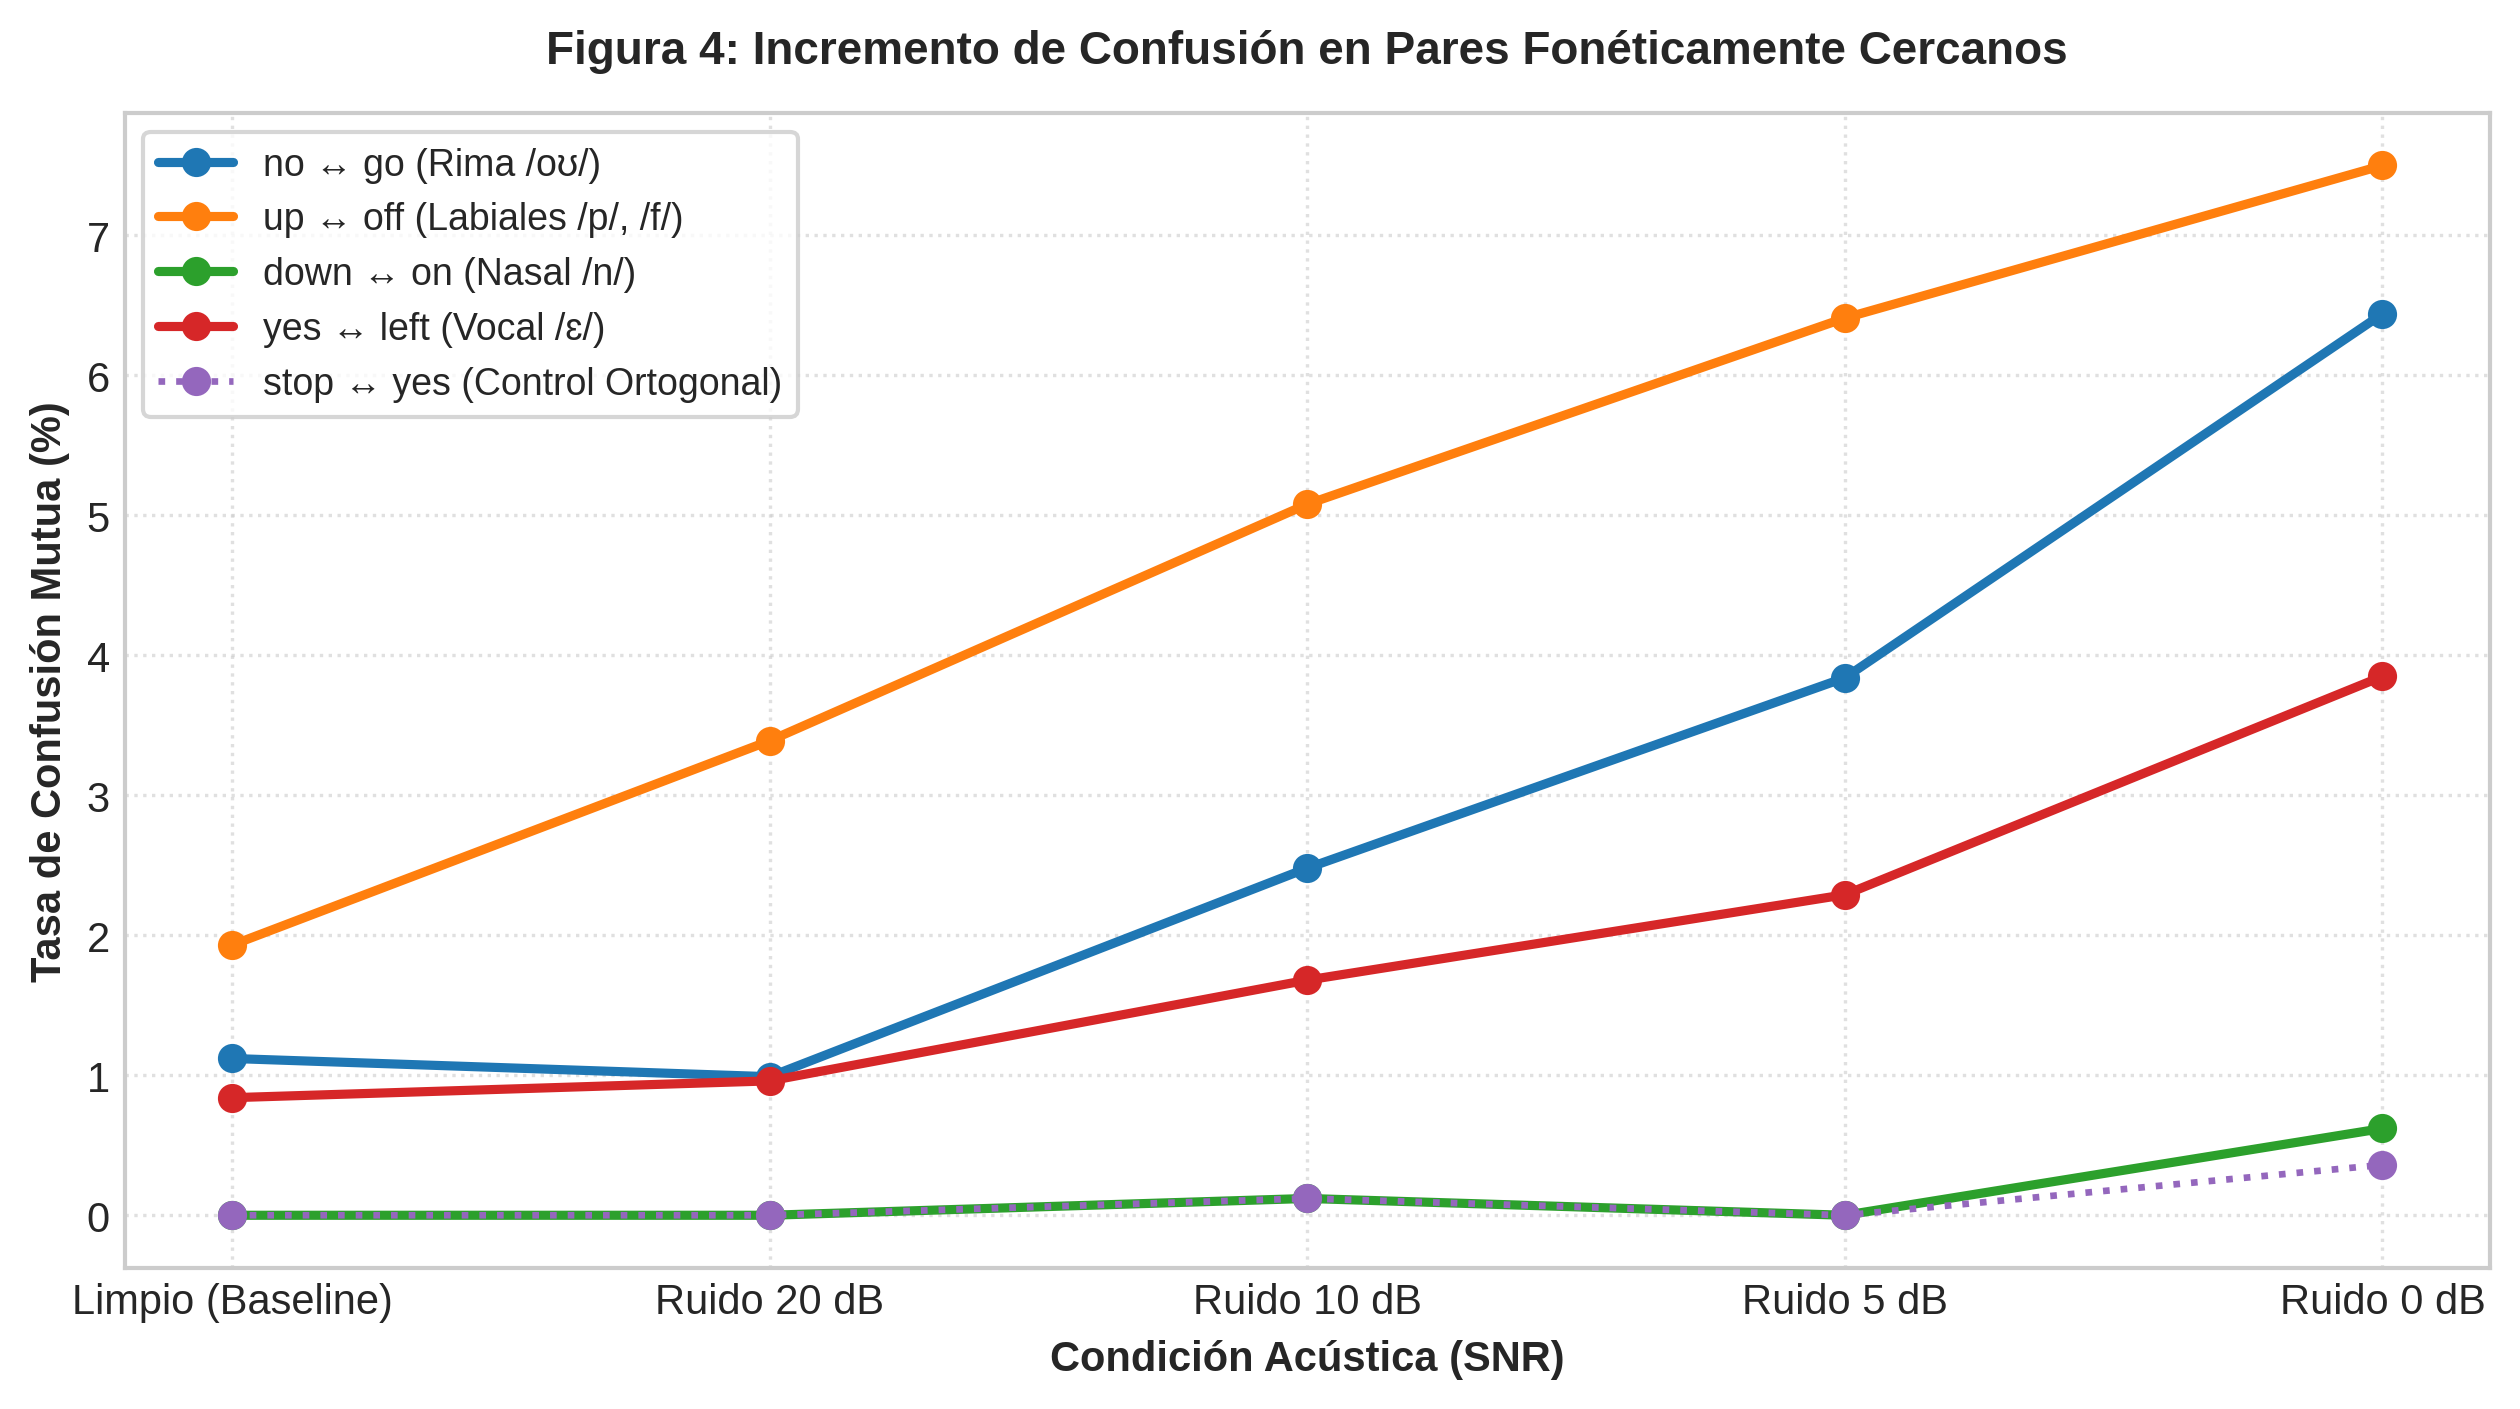

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Diccionario de pares fonéticos a evaluar
pares_estudio = {
    "no ↔ go (Rima /oʊ/)": ('no', 'go'),
    "up ↔ off (Labiales /p/, /f/)": ('up', 'off'),
    "down ↔ on (Nasal /n/)": ('down', 'on'),
    "yes ↔ left (Vocal /ɛ/)": ('yes', 'left'),
    "stop ↔ yes (Control Ortogonal)": ('stop', 'yes')
}

snr_tags = df_metricas["Condición"].tolist()
evolucion_pares = []

for tag in snr_tags:
    cm = cm_dict[tag]
    fila_par = {"Condición": tag}

    for nombre_par, (palabra_a, palabra_b) in pares_estudio.items():
        idx_a = labels_kws.index(palabra_a)
        idx_b = labels_kws.index(palabra_b)

        # Muestras reales totales de A y B
        total_a = cm[idx_a, :].sum()
        total_b = cm[idx_b, :].sum()

        # Confusiones cruzadas: A predicho como B y B predicho como A
        conf_a_b = cm[idx_a, idx_b]
        conf_b_a = cm[idx_b, idx_a]

        # Tasa de confusión cruzada (%)
        tasa_confusion = ((conf_a_b + conf_b_a) / (total_a + total_b + 1e-8)) * 100.0
        fila_par[nombre_par] = round(tasa_confusion, 2)

    evolucion_pares.append(fila_par)

df_pares = pd.DataFrame(evolucion_pares)
print("=== EVOLUCIÓN DE LA TASA DE CONFUSIÓN CRUZADA (%) POR PAR FONÉTICO ===")
display(df_pares)

# =========================================================================
# GRÁFICO: Trayectoria de Confusión Fonética
# =========================================================================
fig, ax = plt.subplots(figsize=(8.5, 4.8), dpi=300)

for nombre_par in pares_estudio.keys():
    estilo = ':' if "Control" in nombre_par else '-'
    ancho = 1.6 if "Control" in nombre_par else 2.2
    ax.plot(df_pares["Condición"], df_pares[nombre_par], marker='o', lw=ancho, linestyle=estilo, label=nombre_par)

ax.set_title("Figura 4: Incremento de Confusión en Pares Fonéticamente Cercanos", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Condición Acústica (SNR)", fontsize=10, fontweight='bold')
ax.set_ylabel("Tasa de Confusión Mutua (%)", fontsize=10, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(frameon=True, loc='upper left', fontsize=9)

plt.savefig("figura4_confusion_pares_foneticos.png", dpi=300)
plt.show()